# Audit & Full Recount

This notebook re-derives every count from scratch, audits the results published in
notebooks 01/02 and the README, and reports the **full method grid** that TASK.txt asks for:
counts *by lemma, by root, by POS filter (noun, adjective, proper noun, verb), by number
(singular vs plural/dual), and combinations thereof* — plus, for every root, **all lemmas
under that root with their counts**.

**Corrections found by this audit** (evidence in section 2):

1. **Izam (bones) was undercounted 2 → 15.** The corpus tags the plural عظام (ʿiẓām)
   under `LEM:EaZiym` — the same lemma as عظيم "great" — distinguishable only as
   `POS:N` + `MP` entries. The prior count used `LEM:EaZom` alone and missed all 13
   plural occurrences, including the embryology verses (23:14 twice).
2. **Akhira masculine remainder is 40, not 30** (lemma `A^xir` totals 155 = 115 feminine
   "hereafter" + 40 masculine "last/latter"; README claimed 115 + 30).
3. **Barr split was wrong on both numbers.** README claimed "land 13× + righteous 9×";
   the data gives land **12**, righteous/dutiful **10** (3 singular incl. the divine name
   in 52:28, 6 plural أبرار, 1 بررة), total 22.
4. **Asymmetric variant treatment in the Hayat/Mawt pair.** Mawt was credited the variant
   nouns `mawotat` (3) + `mamaAt` (3) → 56, but Hayat was not credited its exact
   counterparts `m~aHoyaA` (2) + `HayawaAn` (1) → 79. 6:162 even pairs مَحْيَا with
   مَمَات in the same verse. Variants are now applied symmetrically.
5. **The task list has 38 words, not 37** as the README stated.

Source: Quranic Arabic Corpus morphology v0.4 (77,915 STEM entries), Buckwalter transliteration.

## Methodology (read this first)

- **Data**: every word of the Quran, morphologically tagged, one row per word *segment*. We count
  **STEM segments only** — prefixes (e.g. the article الـ) and suffixes (pronouns, case endings)
  are not words. 77,915 STEM entries total (verified against the raw file below).
- **Lemma count** = rows whose `LEM` equals the word's dictionary headword. The corpus files
  regular plurals, duals, and many broken plurals under the same lemma, so this is "the word in
  all its grammatical forms".
- **Variants** = same-meaning nouns or irregular plurals that the corpus stores under a *different*
  lemma (e.g. rijaAl "men" for rajul). Each variant is listed explicitly in the config with a note.
- **By number**: Singular / Dual / Plural split of the lemma rows, from the corpus's
  person-gender-number tags. Unmarked number = singular (Arabic leaves singular implicit).
- **By POS**: the same rows split by part of speech (N noun, ADJ adjective, PN proper noun,
  V verb, T time adverb); and the whole **root** split the same way, since TASK.txt asks for
  counts by root and by POS filter.
- **One gender filter**: Akhira only — fem آخرة "hereafter" vs masc آخِر "last" share one lemma
  and are genuinely different words (evidence in 2.2). No other word is filtered.
- **Verifiability**: `output/full_counts.csv` holds the grid; `output/occurrences.csv` lists
  **every counted occurrence with its chapter:verse:word location**, so any cell of the grid can
  be checked by hand against a Quran text or https://corpus.quran.com. Sanity-check asserts in
  section 3.1 tie the grid to independently audited values.
- Every word gets every method — no cherry-picking.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
from src.parser import load_morphology
from src.buckwalter import bw_to_arabic

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 250)

df = load_morphology()

# Sanity check the parser against the raw file: count lines whose FEATURES field starts with STEM
raw_stem = 0
with open("../data/quranic-corpus-morphology-0.4.txt", encoding="utf-8") as f:
    for line in f:
        parts = line.rstrip("\n").split("\t")
        if len(parts) == 4 and parts[3].startswith("STEM"):
            raw_stem += 1
assert raw_stem == len(df) == 77915, (raw_stem, len(df))
print(f"STEM entries: {len(df):,} (parser output matches raw file)")

STEM entries: 77,915 (parser output matches raw file)


## 1. Helpers

`NUMBER` comes from the trailing S/D/P of person-gender-number flags (`3MS`, `MP`, `FD`, bare `P`, ...).
Entries with no number flag are unmarked singulars (Arabic leaves singular number implicit on most nouns),
so "singular" below means *not marked dual or plural*.

In [2]:
def lemma_breakdown(lem):
    """POS x NUMBER x PGN breakdown of one lemma, with surface forms."""
    sub = df[df.LEM == lem]
    g = (sub.groupby(["POS", sub.NUMBER.fillna("S(unmarked)"), sub.PGN.fillna("-")])
            .size().reset_index(name="count"))
    g.columns = ["POS", "NUMBER", "PGN", "count"]
    print(f"LEM:{lem} [{bw_to_arabic(lem)}]  total={len(sub)}")
    print(g.to_string(index=False))
    forms = sub.groupby("form").size().sort_values(ascending=False)
    print("forms:", {f"{f} [{bw_to_arabic(f)}]": int(n) for f, n in forms.head(10).items()})


def root_listing(root):
    """All lemmas under a root: POS x NUMBER, with Arabic. (TASK.txt: 'list all lemmas under that root'.)"""
    sub = df[df.ROOT == root]
    g = (sub.groupby(["LEM", "POS", sub.NUMBER.fillna("S")])
            .size().reset_index(name="count")
            .sort_values("count", ascending=False).reset_index(drop=True))
    g.columns = ["LEM", "POS", "NUMBER", "count"]
    g.insert(1, "Arabic", g.LEM.map(bw_to_arabic))
    return g

## 2. Audit evidence

### 2.1 Izam (bones): the plural عظام hides under `LEM:EaZiym`

In [3]:
display(root_listing("EZm"))

bones_pl = df[(df.LEM == "EaZiym") & (df.POS == "N") & (df.NUMBER == "P")]
print(f"EaZiym entries that are actually 'bones' (N + plural): {len(bones_pl)}")
display(bones_pl[["chapter", "verse", "word", "form", "raw_features"]])

# The 3 N-singular EaZiym entries are 'great' used substantively, NOT bones:
not_bones = df[(df.LEM == "EaZiym") & (df.POS == "N") & (df.NUMBER != "P")]
display(not_bones[["chapter", "verse", "form", "raw_features"]])

bones_sg = df[df.LEM == "EaZom"]
print(f"\nCorrected bones count: EaZom (sg) {len(bones_sg)} + EiZa`m plural {len(bones_pl)} = "
      f"{len(bones_sg) + len(bones_pl)}   (prior notebooks reported 2)")

,LEM,Arabic,POS,NUMBER,count
0,EaZiym,عَظِيم,ADJ,S,104
1,EaZiym,عَظِيم,N,P,13
2,EaZiym,عَظِيم,N,S,3
3,>aEoZam,أَعْظَم,N,S,2
4,EaZom,عَظْم,N,S,2
5,yuEaZ~imo,يُعَظِّمْ,V,S,2
6,>aEoZam,أَعْظَم,ADJ,S,1
7,yuEoZimo,يُعْظِمْ,V,S,1


EaZiym entries that are actually 'bones' (N + plural): 13


,chapter,verse,word,form,raw_features
5407,2,259,51,EiZaAmi,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MP|GEN
36912,17,49,4,EiZa`mFA,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MP|INDEF|ACC
37624,17,98,9,EiZa`mFA,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MP|INDEF|ACC
44250,23,14,10,EiZa`mFA,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MP|INDEF|ACC
44252,23,14,12,EiZa`ma,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MP|ACC
44516,23,35,7,EiZa`mFA,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MP|INDEF|ACC
44909,23,82,6,EiZa`mFA,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MP|INDEF|ACC
57738,36,78,9,EiZa`ma,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MP|ACC
57875,37,16,5,EiZa`mFA,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MP|INDEF|ACC
58064,37,53,5,EiZa`mFA,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MP|INDEF|ACC


,chapter,verse,form,raw_features
12255,4,113,EaZiymFA,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MS|INDEF|ACC
45453,24,15,EaZiymN,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MS|INDEF|NOM
69634,56,76,EaZiymN,STEM|POS:N|LEM:EaZiym|ROOT:EZm|MS|INDEF|NOM



Corrected bones count: EaZom (sg) 2 + EiZa`m plural 13 = 15   (prior notebooks reported 2)


### 2.2 Akhira: lemma `A^xir` = 155 total, 115 feminine (hereafter) + 40 masculine (last/latter)

README claimed 115 + 30 = 145. The masculine remainder is 40. The separate lemma `A^xar`
(آخَر "another", 70×) is not involved either way.

In [4]:
ax = df[df.LEM == "A^xir"]
print(f"A^xir total: {len(ax)}")
print(ax.groupby(["POS", ax.PGN.fillna("-")]).size().to_string())
fem = ax[ax.PGN.str.contains("F", na=False)]
print(f"\nFeminine (the hereafter): {len(fem)}  — all forms are 'aAxirap* (آخرة)")
print(f"Masculine/unmarked (last/latter): {len(ax) - len(fem)}")
print(f"\nSeparate lemma A^xar (another): {int((df.LEM == 'A^xar').sum())}")

A^xir total: 155
POS  PGN
ADJ  FS       4
     MS      17
N    FS     111
     MP      10
     MS      12
T    MS       1

Feminine (the hereafter): 115  — all forms are 'aAxirap* (آخرة)
Masculine/unmarked (last/latter): 40

Separate lemma A^xar (another): 70


### 2.3 Barr: form-level split of lemma `bar~` (22 total)

Every entry shown below. The 12 genitive `bar~i` + (none else) are "the land" (always
"in the land" contexts); 52:28 `bar~u` is the divine name *al-Barr*; the 2 `bar~F[A`
(19:14, 19:32) are "dutiful (to parents)"; أبرار (6) and بررة (1) are "the righteous".
Land = 12, righteous/dutiful = 10. README claimed 13 + 9.

In [5]:
b = df[df.LEM == "bar~"].copy()
b["Arabic_form"] = b.form.map(bw_to_arabic)
display(b[["chapter", "verse", "form", "Arabic_form", "POS", "raw_features"]]
        .sort_values(["chapter", "verse"]).reset_index(drop=True))
land = b[b.form.isin(["bar~i"])]
print(f"land (bar~i, 'in the land'): {len(land)}")
print(f"righteous/dutiful (everything else, incl. divine name 52:28): {len(b) - len(land)}")
print(f"\nNote: bir~ (بِرّ righteousness, 8x) is a separate lemma — see root listing for brr below.")

,chapter,verse,form,Arabic_form,POS,raw_features
0,3,193,>aboraAri,أَبْرَارِ,N,STEM|POS:N|LEM:bar~|ROOT:brr|MP|GEN
1,3,198,>aboraAri,أَبْرَارِ,N,STEM|POS:N|LEM:bar~|ROOT:brr|MP|GEN
2,5,96,bar~i,بَرِّ,N,STEM|POS:N|LEM:bar~|ROOT:brr|M|GEN
3,6,59,bar~i,بَرِّ,N,STEM|POS:N|LEM:bar~|ROOT:brr|M|GEN
4,6,63,bar~i,بَرِّ,N,STEM|POS:N|LEM:bar~|ROOT:brr|M|GEN
5,6,97,bar~i,بَرِّ,N,STEM|POS:N|LEM:bar~|ROOT:brr|M|GEN
6,10,22,bar~i,بَرِّ,N,STEM|POS:N|LEM:bar~|ROOT:brr|M|GEN
7,17,67,bar~i,بَرِّ,N,STEM|POS:N|LEM:bar~|ROOT:brr|M|GEN
8,17,68,bar~i,بَرِّ,N,STEM|POS:N|LEM:bar~|ROOT:brr|M|GEN
9,17,70,bar~i,بَرِّ,N,STEM|POS:N|LEM:bar~|ROOT:brr|M|GEN


land (bar~i, 'in the land'): 12
righteous/dutiful (everything else, incl. divine name 52:28): 10

Note: bir~ (بِرّ righteousness, 8x) is a separate lemma — see root listing for brr below.


### 2.4 Hayat/Mawt variant symmetry

`mamaAt` (مَمَات, death) and `m~aHoyaA` (مَحْيَا, life) are the same noun pattern and are
paired in 6:162 itself; `HayawaAn` (حَيَوَان, 29:64) is explicitly "the true life".
Crediting only the death-side variants (as the prior notebooks did) skews the pair.

In [6]:
for lem in ["mawot", "mawotat", "mamaAt", "Hayaw`p", "m~aHoyaA", "HayawaAn"]:
    sub = df[df.LEM == lem]
    print(f"  {lem:<10} [{bw_to_arabic(lem)}]  {len(sub)}")
six162 = df[(df.chapter == 6) & (df.verse == 162) & df.LEM.isin(["m~aHoyaA", "mamaAt"])]
print("\n6:162 contains both:")
display(six162[["chapter", "verse", "word", "form", "LEM", "raw_features"]])
print(f"Mawt + variants:  50 + 3 + 3 = {50+3+3}")
print(f"Hayat + variants: 76 + 2 + 1 = {76+2+1}")

  mawot      [مَوْت]  50
  mawotat    [مَوْتَت]  3
  mamaAt     [مَمَات]  3
  Hayaw`p    [حَيَوٰة]  76
  m~aHoyaA   [مَّحْيَا]  2
  HayawaAn   [حَيَوَان]  1

6:162 contains both:


,chapter,verse,word,form,LEM,raw_features
19307,6,162,5,maHoyaA,m~aHoyaA,STEM|POS:N|LEM:m~aHoyaA|ROOT:Hyy|M|ACC
19308,6,162,6,mamaAti,mamaAt,STEM|POS:N|LEM:mamaAt|ROOT:mwt|M|ACC


Mawt + variants:  50 + 3 + 3 = 56
Hayat + variants: 76 + 2 + 1 = 79


### 2.5 Smaller audit notes (all verified against the raw file)

- **Plurals inside the same lemma**: the corpus files regular *and many broken* plurals under
  the singular's lemma, marked `MP`/`FP`/`MD`/`FD`/`P`: malak includes ملائكة (73 pl + 2 dual),
  shaytan includes شياطين (18 pl), yawm includes أيام (27 pl) and يومين (3 dual), shahr includes
  أشهر/شهور (7 pl + 2 dual), jannah includes جنات (71 pl + 8 dual), insan includes أناس/أناسي (6 pl),
  bahr includes أبحر/بحار (3 pl + 5 dual). The "Singular" column below excludes D/P uniformly.
- **niswa** (نسوة, 12:30) is tagged under `LEM:nisaA^'` — so the women-plural lemma count (59) already includes it.
- **yawma'idhin** (يومئذ, "that day", 70×) is its own lemma `yawoma}i*` and is *not* part of yawm's 405.
- **Separate-lemma broken plurals** still exist too (rijaAl for rajul, nisaA^' for imra'a,
  Hasana`t/say~i_#aAt, EiZa`m-under-EaZiym) — these are the explicit variant selectors below.
- TASK.txt lists **38 words** (README said 37).

## 3. Full recount — uniform method grid

Word configuration. `variants` are irregular/suppletive plurals or same-meaning variant nouns
whose occurrences live under a *different* lemma. A variant selector is `(lemma, pos, number)`
with `None` = no constraint; the bones plural needs `("EaZiym", "N", "P")` because of the
tagging quirk shown in 2.1. The Akhira gender filter is the only gender filter (masc `A^xir`
"last" is a different word from fem `A^xirap` "hereafter").

Every word gets every method. No cherry-picking.

In [7]:
WORDS = [
    # name, arabic, primary lemmas, variant selectors [(lem, pos, number)], root, gender_filter, note
    ("Dunya", "دنيا", ["d~unoyaA"], [], "dnw", None, ""),
    ("Akhira", "آخرة", ["A^xir"], [], "Axr", "F",
     "Fem 'hereafter' only; masc 'last/latter' (40x) is a different word sharing the lemma."),
    ("Malak (angel)", "ملك", ["malak"], [], "mlk", None,
     "Includes ملائكة (73 pl + 2 dual). Root mlk also has malik(king), mulk(dominion) — different lemmas."),
    ("Shaytan", "شيطان", ["$ayoTa`n"], [], "$Tn", None, "Includes شياطين (18 pl)."),
    ("Hayat", "حياة", ["Hayaw`p"], [("m~aHoyaA", None, None), ("HayawaAn", None, None)], "Hyy", None,
     "Variants: maHyaA(2), HayawaAn(1) — symmetric with Mawt's variants (see 2.4)."),
    ("Mawt", "موت", ["mawot"], [("mawotat", None, None), ("mamaAt", None, None)], "mwt", None,
     "Variants: mawotat(3), mamaAt(3)."),
    ("Rajul", "رجل", ["rajul"], [("rijaAl", None, None)], "rjl", None,
     "rijaAl(28) = broken plural. rijol(15) = feet, different word."),
    ("Imra'a", "امرأة", ["{mora>at"], [("nisaA^'", None, None)], "mrA", None,
     "nisaA''(59, incl. niswa 2x) = suppletive plural, root nsw."),
    ("Shahr", "شهر", ["$ahor"], [], "$hr", None, "Includes أشهر/شهور (7 pl + 2 dual)."),
    ("Yawm", "يوم", ["yawom"], [], "ywm", None,
     "Includes أيام (27 pl) + يومين (3 dual). yawma'idhin (70x) is a separate lemma."),
    ("Bahr", "بحر", ["baHor"], [], "bHr", None, "Includes أبحر/بحار (3 pl + 5 dual)."),
    ("Barr", "بر", ["bar~"], [], "brr", None,
     "Lemma conflates land(12) + righteous/dutiful(10) — see 2.3. bir~(8) is a separate lemma."),
    ("Jannah", "جنة", ["jan~ap"], [], "jnn", None,
     "Includes جنات (71 pl + 8 dual). Root jnn also has jinn, majnun — different lemmas."),
    ("Jahannam", "جهنم", ["jahan~am"], [], None, None, "Proper noun, no root in corpus."),
    ("Harr", "حر", ["Har~"], [("Haruwr", None, None)], "Hrr", None,
     "Haruwr(1) = scorching heat. Hur~(2) = free man, different word."),
    ("Bard", "برد", ["barod"], [("baArid", None, None)], "brd", None,
     "baArid(2) = cold (adj). barad(1) = hail, excluded."),
    ("Zakat", "زكاة", ["zakaw`p"], [], "zkw", None, ""),
    ("Baraka", "بركة", ["baraka`t"], [("mubaArak", None, None), ("m~uba`rakap", None, None)], "brk", None,
     "Singular بركة does not occur; barakat(3) is the plural. Variants = blessed (adj/noun)."),
    ("Qaala", "قال", ["qaAla"], [], "qwl", None, "Verb — full form breakdown in section 6."),
    ("Adhab", "عذاب", ["Ea*aAb"], [], "E*b", None, ""),
    ("Rahma", "رحمة", ["raHomap"], [], "rHm", None, ""),
    ("Maghfira", "مغفرة", ["m~agofirap"], [("guforaAn", None, None)], "gfr", None, "guforaAn(1) = synonym."),
    ("Ghani", "غني", ["ganiY~"], [], "gny", None, ""),
    ("Faqir", "فقير", ["faqiyr"], [], "fqr", None, ""),
    ("Hasana", "حسنة", ["Hasanap"], [("Hasana`t", None, None)], "Hsn", None, ""),
    ("Sayyi'a", "سيئة", ["say~i}ap"], [("say~i_#aAt", None, None)], "swA", None, ""),
    ("Adam", "آدم", ["A^dam"], [], None, None, "Proper noun, no root."),
    ("Isa", "عيسى", ["EiysaY"], [], None, None, "Proper noun, no root."),
    ("Insan", "إنسان", ["<insa`n"], [("<ins", None, None)], "Ans", None,
     "Lemma includes أناس/أناسي (6 pl). <ins(18) = mankind, collective."),
    ("Iblis", "إبليس", ["<iboliys"], [], None, None, "Proper noun, no root."),
    ("Iman", "إيمان", ["<iyma`n"], [], "Amn", None, ""),
    ("Kufr", "كفر", ["kufor"], [("kuforaAn", None, None), ("kufuwr", None, None)], "kfr", None,
     "kuforaAn(1), kufuwr(3) = variant verbal nouns."),
    ("Turab", "تراب", ["turaAb"], [], "trb", None, ""),
    ("Nutfa", "نطفة", ["n~uTofap"], [], "nTf", None, ""),
    ("Alaqa", "علقة", ["Ealaqap"], [("Ealaq", None, None)], "Elq", None, "Ealaq(1) = 96:2 collective form."),
    ("Mudgha", "مضغة", ["muDogap"], [], "mDg", None, ""),
    ("Izam", "عظم", ["EaZom"], [("EaZiym", "N", "P")], "EZm", None,
     "CORRECTED: plural عظام (13x) is tagged LEM:EaZiym POS:N+MP — see 2.1. Was reported as 2."),
    ("Lahm", "لحم", ["laHom"], [], "lHm", None, ""),
]
assert len(WORDS) == 38

def selector_mask(lem, pos=None, number=None):
    m = df.LEM == lem
    if pos is not None:
        m &= df.POS == pos
    if number is not None:
        m &= df.NUMBER == number
    return m

POS_NOMINAL = ["N", "ADJ", "PN", "T"]

rows = []
for name, arabic, primary, variants, root, gender, note in WORDS:
    lem_mask = df.LEM.isin(primary)
    if gender:
        lem_mask &= df.PGN.str.contains(gender, na=False)
    var_mask = pd.Series(False, index=df.index)
    for v in variants:
        var_mask |= selector_mask(*v)

    prim = df[lem_mask]
    row = {
        "Word": name, "Arabic": arabic, "Lemma(BW)": ", ".join(primary),
        # by lemma
        "Lemma": int(lem_mask.sum()),
        "Lemma+Variants": int((lem_mask | var_mask).sum()),
        # by number (within primary lemma)
        "Singular": int((prim.NUMBER.isna() | (prim.NUMBER == "S")).sum()),
        "Dual": int((prim.NUMBER == "D").sum()),
        "Plural": int((prim.NUMBER == "P").sum()),
        # by POS (within primary lemma)
        "Lem N": int((prim.POS == "N").sum()),
        "Lem ADJ": int((prim.POS == "ADJ").sum()),
        "Lem PN": int((prim.POS == "PN").sum()),
        "Lem V": int((prim.POS == "V").sum()),
        "Lem T": int((prim.POS == "T").sum()),
    }
    # by root, total and per POS filter (noun, adjective, proper noun, verb, time adverb)
    if root:
        r = df[df.ROOT == root]
        row.update({"RootAll": len(r),
                    "Root N": int((r.POS == "N").sum()),
                    "Root ADJ": int((r.POS == "ADJ").sum()),
                    "Root PN": int((r.POS == "PN").sum()),
                    "Root V": int((r.POS == "V").sum()),
                    "Root T": int((r.POS == "T").sum()),
                    "RootNominal": int(r.POS.isin(POS_NOMINAL).sum())})
    else:
        row.update({k: None for k in ["RootAll", "Root N", "Root ADJ", "Root PN", "Root V", "Root T", "RootNominal"]})
    row["Root"] = root or "—"
    row["Note"] = note
    rows.append(row)

grid = pd.DataFrame(rows)
num_cols = ["Lemma", "Lemma+Variants", "Singular", "Dual", "Plural",
            "Lem N", "Lem ADJ", "Lem PN", "Lem V", "Lem T",
            "RootAll", "Root N", "Root ADJ", "Root PN", "Root V", "Root T", "RootNominal"]
grid[num_cols] = grid[num_cols].astype("Int64")  # nullable ints: no floats in the CSV for rootless words
display(grid[["Word", "Arabic", "Lemma(BW)", "Root"] + num_cols].astype(object).fillna("—"))

grid.to_csv("../output/full_counts.csv", index=False)
print("Saved output/full_counts.csv")

print("\nNOTES:")
for _, r in grid[grid.Note != ""].iterrows():
    print(f"  {r['Word']} ({r['Arabic']}): {r['Note']}")

,Word,Arabic,Lemma(BW),Root,Lemma,Lemma+Variants,Singular,Dual,Plural,Lem N,Lem ADJ,Lem PN,Lem V,Lem T,RootAll,Root N,Root ADJ,Root PN,Root V,Root T,RootNominal
0,Dunya,دنيا,d~unoyaA,dnw,115,115,115,0,0,41,74,0,0,0,133,54,76,0,2,1,131
1,Akhira,آخرة,A^xir,Axr,115,115,115,0,0,111,4,0,0,0,250,178,47,0,24,1,226
2,Malak (angel),ملك,malak,mlk,88,88,13,2,73,88,0,0,0,0,206,159,2,1,44,0,162
3,Shaytan,شيطان,$ayoTa`n,$Tn,88,88,70,0,18,8,0,80,0,0,88,8,0,80,0,0,88
4,Hayat,حياة,Hayaw`p,Hyy,76,79,76,0,0,76,0,0,0,0,184,112,1,0,71,0,113
5,Mawt,موت,mawot,mwt,50,56,50,0,0,50,0,0,0,0,165,96,9,0,60,0,105
6,Rajul,رجل,rajul,rjl,29,57,24,5,0,29,0,0,0,0,73,73,0,0,0,0,73
7,Imra'a,امرأة,{mora>at,mrA,26,85,24,2,0,26,0,0,0,0,38,37,1,0,0,0,38
8,Shahr,شهر,$ahor,$hr,21,21,12,2,7,21,0,0,0,0,21,21,0,0,0,0,21
9,Yawm,يوم,yawom,ywm,405,405,375,3,27,325,0,0,0,80,405,325,0,0,0,80,405


Saved output/full_counts.csv

NOTES:
  Akhira (آخرة): Fem 'hereafter' only; masc 'last/latter' (40x) is a different word sharing the lemma.
  Malak (angel) (ملك): Includes ملائكة (73 pl + 2 dual). Root mlk also has malik(king), mulk(dominion) — different lemmas.
  Shaytan (شيطان): Includes شياطين (18 pl).
  Hayat (حياة): Variants: maHyaA(2), HayawaAn(1) — symmetric with Mawt's variants (see 2.4).
  Mawt (موت): Variants: mawotat(3), mamaAt(3).
  Rajul (رجل): rijaAl(28) = broken plural. rijol(15) = feet, different word.
  Imra'a (امرأة): nisaA''(59, incl. niswa 2x) = suppletive plural, root nsw.
  Shahr (شهر): Includes أشهر/شهور (7 pl + 2 dual).
  Yawm (يوم): Includes أيام (27 pl) + يومين (3 dual). yawma'idhin (70x) is a separate lemma.
  Bahr (بحر): Includes أبحر/بحار (3 pl + 5 dual).
  Barr (بر): Lemma conflates land(12) + righteous/dutiful(10) — see 2.3. bir~(8) is a separate lemma.
  Jannah (جنة): Includes جنات (71 pl + 8 dual). Root jnn also has jinn, majnun — different lemmas.
  Ja

### 3.1 Occurrence index — every counted row, with location

One row per counted occurrence (primary lemma and variants), so every number in the grid can be
verified by hand. `kind` says whether the row is from the primary lemma or a variant selector.

In [8]:
occ_frames = []
for name, arabic, primary, variants, root, gender, note in WORDS:
    lem_mask = df.LEM.isin(primary)
    if gender:
        lem_mask &= df.PGN.str.contains(gender, na=False)
    prim = df[lem_mask].copy()
    prim["kind"] = "primary"
    frames = [prim]
    for v in variants:
        sub = df[selector_mask(*v)].copy()
        sub["kind"] = f"variant:{v[0]}"
        frames.append(sub)
    occ = pd.concat(frames)
    occ.insert(0, "target", name)
    occ_frames.append(occ)

occurrences = pd.concat(occ_frames)
occurrences["location"] = (occurrences.chapter.astype(str) + ":" +
                           occurrences.verse.astype(str) + ":" + occurrences.word.astype(str))
occurrences["form_arabic"] = occurrences.form.map(bw_to_arabic)
out_cols = ["target", "location", "form", "form_arabic", "LEM", "POS", "NUMBER", "PGN", "kind"]
occurrences[out_cols].to_csv("../output/occurrences.csv", index=False)
print(f"Saved output/occurrences.csv ({len(occurrences)} rows)")

# the index must agree with the grid exactly
per_word = occurrences.groupby("target").size()
for _, r in grid.iterrows():
    assert per_word[r["Word"]] == r["Lemma+Variants"], r["Word"]
print("Occurrence index matches the Lemma+Variants column for all 38 words.")

print("\nExample — all 15 counted occurrences of Izam (bones):")
display(occurrences[occurrences.target == "Izam"][out_cols].reset_index(drop=True))

Saved output/occurrences.csv (3960 rows)
Occurrence index matches the Lemma+Variants column for all 38 words.

Example — all 15 counted occurrences of Izam (bones):


,target,location,form,form_arabic,LEM,POS,NUMBER,PGN,kind
0,Izam,6:146:23,EaZomK,عَظْمٍ,EaZom,N,NaN,NaN,primary
1,Izam,19:4:5,EaZomu,عَظْمُ,EaZom,N,NaN,NaN,primary
2,Izam,2:259:51,EiZaAmi,عِظَامِ,EaZiym,N,P,MP,variant:EaZiym
3,Izam,17:49:4,EiZa`mFA,عِظَٰمًا,EaZiym,N,P,MP,variant:EaZiym
4,Izam,17:98:9,EiZa`mFA,عِظَٰمًا,EaZiym,N,P,MP,variant:EaZiym
5,Izam,23:14:10,EiZa`mFA,عِظَٰمًا,EaZiym,N,P,MP,variant:EaZiym
6,Izam,23:14:12,EiZa`ma,عِظَٰمَ,EaZiym,N,P,MP,variant:EaZiym
7,Izam,23:35:7,EiZa`mFA,عِظَٰمًا,EaZiym,N,P,MP,variant:EaZiym
8,Izam,23:82:6,EiZa`mFA,عِظَٰمًا,EaZiym,N,P,MP,variant:EaZiym
9,Izam,36:78:9,EiZa`ma,عِظَٰمَ,EaZiym,N,P,MP,variant:EaZiym


### 3.2 Sanity checks against the audit

In [9]:
g = grid.set_index("Word")
checks = {
    ("Izam", "Lemma+Variants"): 15,
    ("Izam", "Lemma"): 2,
    ("Akhira", "Lemma"): 115,
    ("Dunya", "Lemma"): 115,
    ("Malak (angel)", "Lemma"): 88,
    ("Shaytan", "Lemma"): 88,
    ("Adam", "Lemma"): 25,
    ("Isa", "Lemma"): 25,
    ("Yawm", "Lemma"): 405,
    ("Yawm", "Singular"): 375,
    ("Shahr", "Singular"): 12,
    ("Hayat", "Lemma+Variants"): 79,
    ("Mawt", "Lemma+Variants"): 56,
    ("Rahma", "Lemma"): 114,
    ("Qaala", "Lemma"): 1618,
    ("Zakat", "Lemma"): 32,
}
for (w, col), expected in checks.items():
    actual = g.loc[w, col]
    assert actual == expected, (w, col, actual, expected)
print(f"All {len(checks)} sanity checks pass.")

All 16 sanity checks pass.


## 4. Per-word lemma breakdowns (POS × number × PGN)

The "combinations thereof" view: every primary lemma broken down by POS, number, and PGN,
with surface forms.

In [10]:
for name, arabic, primary, variants, root, gender, note in WORDS:
    print("=" * 90)
    print(f"{name} ({arabic})")
    for lem in primary:
        lemma_breakdown(lem)
    for v in variants:
        sub = df[selector_mask(*v)]
        constraint = "".join(f" {x}" for x in v[1:] if x)
        print(f"  variant {v[0]} [{bw_to_arabic(v[0])}]{constraint}: {len(sub)}")
    print()

Dunya (دنيا)
LEM:d~unoyaA [دُّنْيَا]  total=115
POS NUMBER PGN  count
ADJ      S  FS     74
  N      S  FS     41
forms: {'d~unoyaA [دُّنْيَا]': 110, 'd~unoyaA^ [دُّنْيَآ]': 5}

Akhira (آخرة)
LEM:A^xir [آخِر]  total=155
POS NUMBER PGN  count
ADJ      S  FS      4
ADJ      S  MS     17
  N      P  MP     10
  N      S  FS    111
  N      S  MS     12
  T      S  MS      1
forms: {"'aAxirapi [ءَاخِرَةِ]": 92, "'aAxiri [ءَاخِرِ]": 24, "'aAxirapa [ءَاخِرَةَ]": 13, "'aAxirapu [ءَاخِرَةُ]": 10, "'aAxiriyna [ءَاخِرِينَ]": 10, "'aAxira [ءَاخِرَ]": 4, "'aAxiru [ءَاخِرُ]": 2}

Malak (angel) (ملك)
LEM:malak [مَلَك]  total=88
POS      NUMBER PGN  count
  N           D  MD      2
  N           P  MP     73
  N S(unmarked)   -     13
forms: {'mala`^}ikapu [مَلَٰٓئِكَةُ]': 31, 'mala`^}ikapi [مَلَٰٓئِكَةِ]': 22, 'mala`^}ikapa [مَلَٰٓئِكَةَ]': 9, 'malakN [مَلَكٌ]': 6, 'mala`^}ikapF [مَلَٰٓئِكَةً]': 3, 'mala`^}ikati [مَلَٰٓئِكَتِ]': 3, 'malakFA [مَلَكًا]': 3, 'mala`^}ikapN [مَلَٰٓئِكَةٌ]': 2, 'malakay

LEM:{mora>at [ٱمْرَأَت]  total=26
POS      NUMBER PGN  count
  N           D  FD      2
  N S(unmarked)   -     24
forms: {'{mora>ata [ٱمْرَأَتَ]': 9, '{mora>atu [ٱمْرَأَتُ]': 7, '{mora>ati [ٱمْرَأَتِ]': 4, '{mora>apF [ٱمْرَأَةً]': 2, '{mora>apN [ٱمْرَأَةٌ]': 2, '{mora>ataAni [ٱمْرَأَتَانِ]': 1, '{mora>atayoni [ٱمْرَأَتَيْنِ]': 1}
  variant nisaA^' [نِسَآء]: 59

Shahr (شهر)
LEM:$ahor [شَهْر]  total=21
POS      NUMBER PGN  count
  N           D  MD      2
  N           P  MP      7
  N S(unmarked)   -     12
forms: {'>a$ohurK [أَشْهُرٍ]': 4, '$~ahora [شَّهْرَ]': 3, '$ahorFA [شَهْرًا]': 2, '$ahorN [شَهْرٌ]': 2, '$ahorayoni [شَهْرَيْنِ]': 2, '$~ahori [شَّهْرِ]': 2, '$ahorK [شَهْرٍ]': 1, '$ahoru [شَهْرُ]': 1, '$~ahoru [شَّهْرُ]': 1, '$~uhuwri [شُّهُورِ]': 1}

Yawm (يوم)
LEM:yawom [يَوْم]  total=405
POS      NUMBER PGN  count
  N           D  MD      3
  N           P  MP     25
  N S(unmarked)   -    297
  T           P  FP      1
  T           P  MP      1
  T S(unmarked)   -     78
form

LEM:kufor [كُفْر]  total=37
POS      NUMBER PGN  count
  N S(unmarked)   -     37
forms: {'kufori [كُفْرِ]': 17, 'kuforFA [كُفْرًا]': 8, 'kufora [كُفْرَ]': 6, 'kuforu [كُفْرُ]': 5, 'kuforN[ [كُفْرٌۢ]': 1}


  variant kuforaAn [كُفْرَان]: 1


  variant kufuwr [كُفُور]: 3

Turab (تراب)
LEM:turaAb [تُرَاب]  total=17
POS      NUMBER PGN  count
  N S(unmarked)   -     17
forms: {'turaAbFA [تُرَابًا]': 6, 'turaAbK [تُرَابٍ]': 6, 'tura`bFA [تُرَٰبًا]': 2, 'turaAbN [تُرَابٌ]': 1, 'tura`bF[A [تُرَٰبًۢا]': 1, 't~uraAbi [تُّرَابِ]': 1}

Nutfa (نطفة)
LEM:n~uTofap [نُّطْفَة]  total=12
POS      NUMBER PGN  count
  N           S  FS      1
  N S(unmarked)   -     11
forms: {'n~uTofapK [نُّطْفَةٍ]': 9, 'nuTofapF [نُطْفَةً]': 2, 'n~uTofapa [نُّطْفَةَ]': 1}

Alaqa (علقة)
LEM:Ealaqap [عَلَقَة]  total=5
POS      NUMBER PGN  count
  N S(unmarked)   -      5
forms: {'EalaqapF [عَلَقَةً]': 2, 'EalaqapK [عَلَقَةٍ]': 2, 'Ealaqapa [عَلَقَةَ]': 1}
  variant Ealaq [عَلَق]: 1

Mudgha (مضغة)
LEM:muDogap [مُضْغَة]  total=3
POS      NUMBER PGN  count
  N S(unmarked)   -      3
forms: {'muDogapF [مُضْغَةً]': 1, 'muDogapa [مُضْغَةَ]': 1, 'm~uDogapK [مُّضْغَةٍ]': 1}

Izam (عظم)
LEM:EaZom [عَظْم]  total=2
POS      NUMBER PGN  count
  N S(unmarked)   -      2

## 5. Root listings — all lemmas under each root, with counts

TASK.txt: *"For roots with multiple derived words, list all lemmas under that root with their counts."*
(Proper nouns Jahannam, Adam, Isa, Iblis have no root in the corpus.)

In [11]:
roots_seen = []
for name, arabic, primary, variants, root, gender, note in WORDS:
    if not root or root in roots_seen:
        continue
    roots_seen.append(root)
    print(f"=== {name} ({arabic}) — ROOT:{root} — {int((df.ROOT == root).sum())} entries ===")
    print(root_listing(root).to_string(index=False))
    print()
# the suppletive plural of imra'a lives under its own root:
print(f"=== (Imra'a plural) — ROOT:nsw — {int((df.ROOT == 'nsw').sum())} entries ===")
print(root_listing("nsw").to_string(index=False))

=== Dunya (دنيا) — ROOT:dnw — 133 entries ===


     LEM   Arabic POS NUMBER  count
d~unoyaA دُّنْيَا ADJ      S     74
d~unoyaA دُّنْيَا   N      S     41
>adonaY` أَدْنَىٰ   N      S     10
daAniyap دَانِيَة   N      S      2
>adonaY` أَدْنَىٰ ADJ      S      1
>adonaY` أَدْنَىٰ   T      S      1
    daAn     دَان   N      S      1
daAniyap دَانِيَة ADJ      S      1
   danaA    دَنَا   V      P      1
   danaA    دَنَا   V      S      1

=== Akhira (آخرة) — ROOT:Axr — 250 entries ===
            LEM          Arabic POS NUMBER  count
          A^xir           آخِر   N      S    123
          A^xar           آخَر   N      S     25
          A^xir           آخِر ADJ      S     21
          A^xar           آخَر   N      P     17
          A^xar           آخَر ADJ      S     16
        >ax~ara         أَخَّرَ   V      S     13
          A^xar           آخَر ADJ      P     10
          A^xir           آخِر   N      P     10
   yasota>oxiru    يَسْتَأْخِرُ   V      P      6
      ta>ax~ara       تَأَخَّرَ   V      S      3
      

        LEM      Arabic POS NUMBER  count
     Ea*aAb      عَذَاب   N      S    322
    Ea*~aba     عَذَّبَ   V      S     36
    Ea*~aba     عَذَّبَ   V      P      5
muEa*~abiyn مُعَذَّبِين   N      P      4
      Ea*ob       عَذْب   N      S      2
   muEa*~ib    مُعَذِّب   N      P      2
   muEa*~ib    مُعَذِّب   N      S      2

=== Rahma (رحمة) — ROOT:rHm — 339 entries ===
       LEM     Arabic POS NUMBER  count
   raHomap    رَحْمَة   N      S    114
   r~aHiym    رَّحِيم ADJ      S    111
 r~aHoma`n  رَّحْمَٰن   N      S     45
   r~aHima    رَّحِمَ   V      S     19
  >aroHaAm   أَرْحَام   N      P     12
 r~aHoma`n  رَّحْمَٰن ADJ      S     12
   r~aHima    رَّحِمَ   V      P      9
r~a`Himiyn رَّٰحِمِين   N      P      6
   >aroHam    أَرْحَم   N      S      4
   r~aHiym    رَّحِيم   N      S      4
 maroHamap  مَرْحَمَة   N      S      1
     ruHom      رُحْم   N      S      1
   r~aHiym    رَّحِيم ADJ      P      1

=== Maghfira (مغفرة) — ROOT:gfr — 234 entries ===
           LEM         Arabic POS NUMBER  count
        gafuwr         غَفُور   N      S     62
        gafara         غَفَرَ   V      S     59
        gafuwr         غَفُور ADJ      S     29
    m~agofirap     مَّغْفِرَة   N      S     28
   {sotagofara    ٱسْتَغْفَرَ   V      S     22
   {sotagofara    ٱسْتَغْفَرَ   V      P     18
       

        LEM      Arabic POS NUMBER  count
    'aAmana     ءَامَنَ   V      P    462
    mu&omin     مُؤْمِن   N      P    174
    'aAmana     ءَامَنَ   V      S     75
    <iyma`n     إِيمَٰن   N      S     45
    mu&omin     مُؤْمِن   N      S     20
m~u&omina`t مُّؤْمِنَٰت   N      P     18
     >amiyn      أَمِين ADJ      S     14
     >amina      أَمِنَ   V      S     10
  'aAminiyn   ءَامِنِين   N      P     10
     >amina      أَمِنَ   V      P     10
    mu&omin     مُؤْمِن ADJ      P      5
      >amon       أَمْن   N      S      5
  >ama`na`t   أَمَٰنَٰت   N      P      4
     'aAmin      ءَامِن   N      S      4
m~u&omina`t مُّؤْمِنَٰت ADJ      P      4
 m~u&ominap  مُّؤْمِنَة ADJ      S      4
    >amanap     أَمَنَة   N      S      2
   >ama`nat    أَمَٰنَت   N      S      2
    mu&omin     مُؤْمِن ADJ      S      2
     'aAmin      ءَامِن ADJ      S      2
 m~u&ominap  مُّؤْمِنَة   N      S      2
    ma>oman     مَأْمَن   N      S      1
   ma>omuwn    مَأْمُون   N      S



=== Kufr (كفر) — ROOT:kfr — 525 entries ===
      LEM    Arabic POS NUMBER  count
   kafara    كَفَرَ   V      P    248
ka`firuwn كَٰفِرُون   N      P    119
   kafara    كَفَرَ   V      S     41
    kufor     كُفْر   N      S     37
   kaAfir    كَافِر   N      P     22
  kaf~ara   كَفَّرَ   V      S     11
ka`firuwn كَٰفِرُون ADJ      P     10
   kafuwr    كَفُور   N      S      6
   kafuwr    كَفُور ADJ      S      6
   kaAfir    كَافِر   N      S      5
kaf~a`rap كَفَّٰرَة   N      S      4
  kaf~aAr   كَفَّار ADJ      S      4
  kaf~ara   كَفَّرَ   V      P      3
   kufuwr    كُفُور   N      S      3
  kaf~aAr   كَفَّار   N      S      1
  kaAfuwr   كَافُور   N      S      1
 kawaAfir  كَوَافِر   N      P      1
 kaAfirap  كَافِرَة ADJ      S      1
 kuforaAn  كُفْرَان   N      S      1
 >akofara  أَكْفَرَ   V      S      1

=== Turab (تراب) — ROOT:trb — 22 entries ===
       LEM     Arabic POS NUMBER  count
    turaAb     تُرَاب   N      S     17
  >atoraAb   أَتْرَاب   N     

## 6. Qaala (قال) — verb form breakdown

TASK.txt: *"break down by verb form: imperative, perfect 3MP, etc."*

In [12]:
q = df[(df.LEM == "qaAla") & (df.POS == "V")].copy()
print(f"qaAla verb total: {len(q)}\n")

print("By aspect × voice:")
print(q.groupby([q.ASPECT, q.VOICE.fillna("ACT")]).size().to_string(), "\n")

print("By aspect × person-gender-number:")
pivot = q.pivot_table(index=q.PGN.fillna("-"), columns="ASPECT", aggfunc="size", fill_value=0)
pivot["TOTAL"] = pivot.sum(axis=1)
display(pivot.sort_values("TOTAL", ascending=False))

print("Top surface forms:")
forms = q.groupby("form").size().sort_values(ascending=False).head(12)
for f, n in forms.items():
    print(f"  {f:<12} [{bw_to_arabic(f)}]  {n}")

print("\nOther lemmas under ROOT:qwl (non-verb 'saying' nouns):")
print(root_listing("qwl").to_string(index=False))

qaAla verb total: 1618

By aspect × voice:
ASPECT  VOICE
IMPF    ACT      262
        PASS       3
IMPV    ACT      349
PERF    ACT      955
        PASS      49 

By aspect × person-gender-number:


ASPECT,IMPF,IMPV,PERF,TOTAL
PGN,,,,
3MS,77,0,579,656
3MP,119,0,332,451
2MS,8,332,4,344
3FS,6,0,43,49
2MP,27,12,9,48
1P,12,0,27,39
1S,15,0,3,18
3MD,1,0,3,4
2D,0,3,0,3


Top surface forms:
  qaAla        [قَالَ]  531
  qaAlu        [قَالُ]  332
  qulo         [قُلْ]  281
  yaquwlu      [يَقُولُ]  181
  qul          [قُل]  61
  qiyla        [قِيلَ]  49
  quli         [قُلِ]  36
  taquwlu      [تَقُولُ]  33
  qaAlato      [قَالَتْ]  28
  qaAlati      [قَالَتِ]  13
  yaquwla      [يَقُولَ]  12
  quwlu        [قُولُ]  12

Other lemmas under ROOT:qwl (non-verb 'saying' nouns):
      LEM    Arabic POS NUMBER  count
    qaAla     قَالَ   V      S   1068
    qaAla     قَالَ   V      P    541
    qawol     قَوْل   N      S     92
    qaAla     قَالَ   V      D      9
  qaA^}il   قَآئِل   N      S      4
     qiyl      قِيل   N      S      4
taqaw~ala تَقَوَّلَ   V      S      2
>aqaAwiyl أَقَاوِيل   N      S      1
  qaA^}il   قَآئِل   N      P      1


## 7. Corrections vs previously published numbers

In [13]:
corrections = pd.DataFrame([
    ["Izam (bones) count", "2", "15 (2 sg EaZom + 13 pl EiZa`m under LEM:EaZiym)",
     "Corpus tags عظام under lemma EaZiym; prior work missed it (incl. 23:14)."],
    ["Akhira masculine remainder", "30 (README)", "40",
     "A^xir totals 155 = 115 F + 40 M; README's 115+30=145 was wrong."],
    ["Barr semantic split", "land 13 + righteous 9", "land 12 + righteous/dutiful 10",
     "Form-level: bar~i 12 land; 52:28 divine name + 19:14/19:32 dutiful + 7 pl righteous."],
    ["Hayat variants", "none (76)", "+ m~aHoyaA(2) + HayawaAn(1) = 79",
     "Symmetry with Mawt's mawotat/mamaAt variants (6:162 pairs maHyaA with mamaAt)."],
    ["Word count in task", "37 (README)", "38", "TASK.txt lists 38 words."],
], columns=["Item", "Previously published", "Corrected", "Why"])
display(corrections)

confirmed = ("Dunya 115 = Akhira(F) 115;  Malak 88 = Shaytan 88;  Adam 25 = Isa 25;  "
             "Rahma 114;  Adhab 322;  Zakat 32;  Qaala 1618;  Jannah 147 / Jahannam 77;  "
             "Iman 45 / Kufr 37(+4 variants);  Hasana 28(+3) / Sayyi'a 22(+36);  "
             "Rajul 29(+28 rijaAl) / Imra'a 26(+59 nisaA');  Ghani 24 / Faqir 12")
print("Confirmed prior numbers:", confirmed)

,Item,Previously published,Corrected,Why
0,Izam (bones) count,2,15 (2 sg EaZom + 13 pl EiZa`m under LEM:EaZiym),Corpus tags عظام under lemma EaZiym; prior work missed it (incl. 2...
1,Akhira masculine remainder,30 (README),40,A^xir totals 155 = 115 F + 40 M; README's 115+30=145 was wrong.
2,Barr semantic split,land 13 + righteous 9,land 12 + righteous/dutiful 10,Form-level: bar~i 12 land; 52:28 divine name + 19:14/19:32 dutiful...
3,Hayat variants,none (76),+ m~aHoyaA(2) + HayawaAn(1) = 79,Symmetry with Mawt's mawotat/mamaAt variants (6:162 pairs maHyaA w...
4,Word count in task,37 (README),38,TASK.txt lists 38 words.


Confirmed prior numbers: Dunya 115 = Akhira(F) 115;  Malak 88 = Shaytan 88;  Adam 25 = Isa 25;  Rahma 114;  Adhab 322;  Zakat 32;  Qaala 1618;  Jannah 147 / Jahannam 77;  Iman 45 / Kufr 37(+4 variants);  Hasana 28(+3) / Sayyi'a 22(+36);  Rajul 29(+28 rijaAl) / Imra'a 26(+59 nisaA');  Ghani 24 / Faqir 12


## 8. Pairs figure

The PNGs committed before this audit were not reproducible (no generating code; matplotlib
was not even a project dependency) and rendered Arabic reversed, since matplotlib does no
Arabic shaping. This cell regenerates the pairs figure from the audited grid above, as a
dumbbell plot: one row per pair, one dot per word, counts on a log axis (dot *position*,
unlike bar length, stays honest on a log scale). An exact tie renders as a single two-tone
dot. Styling comes from `src/plotstyle.py`, the shared chart style for every figure in this
project.


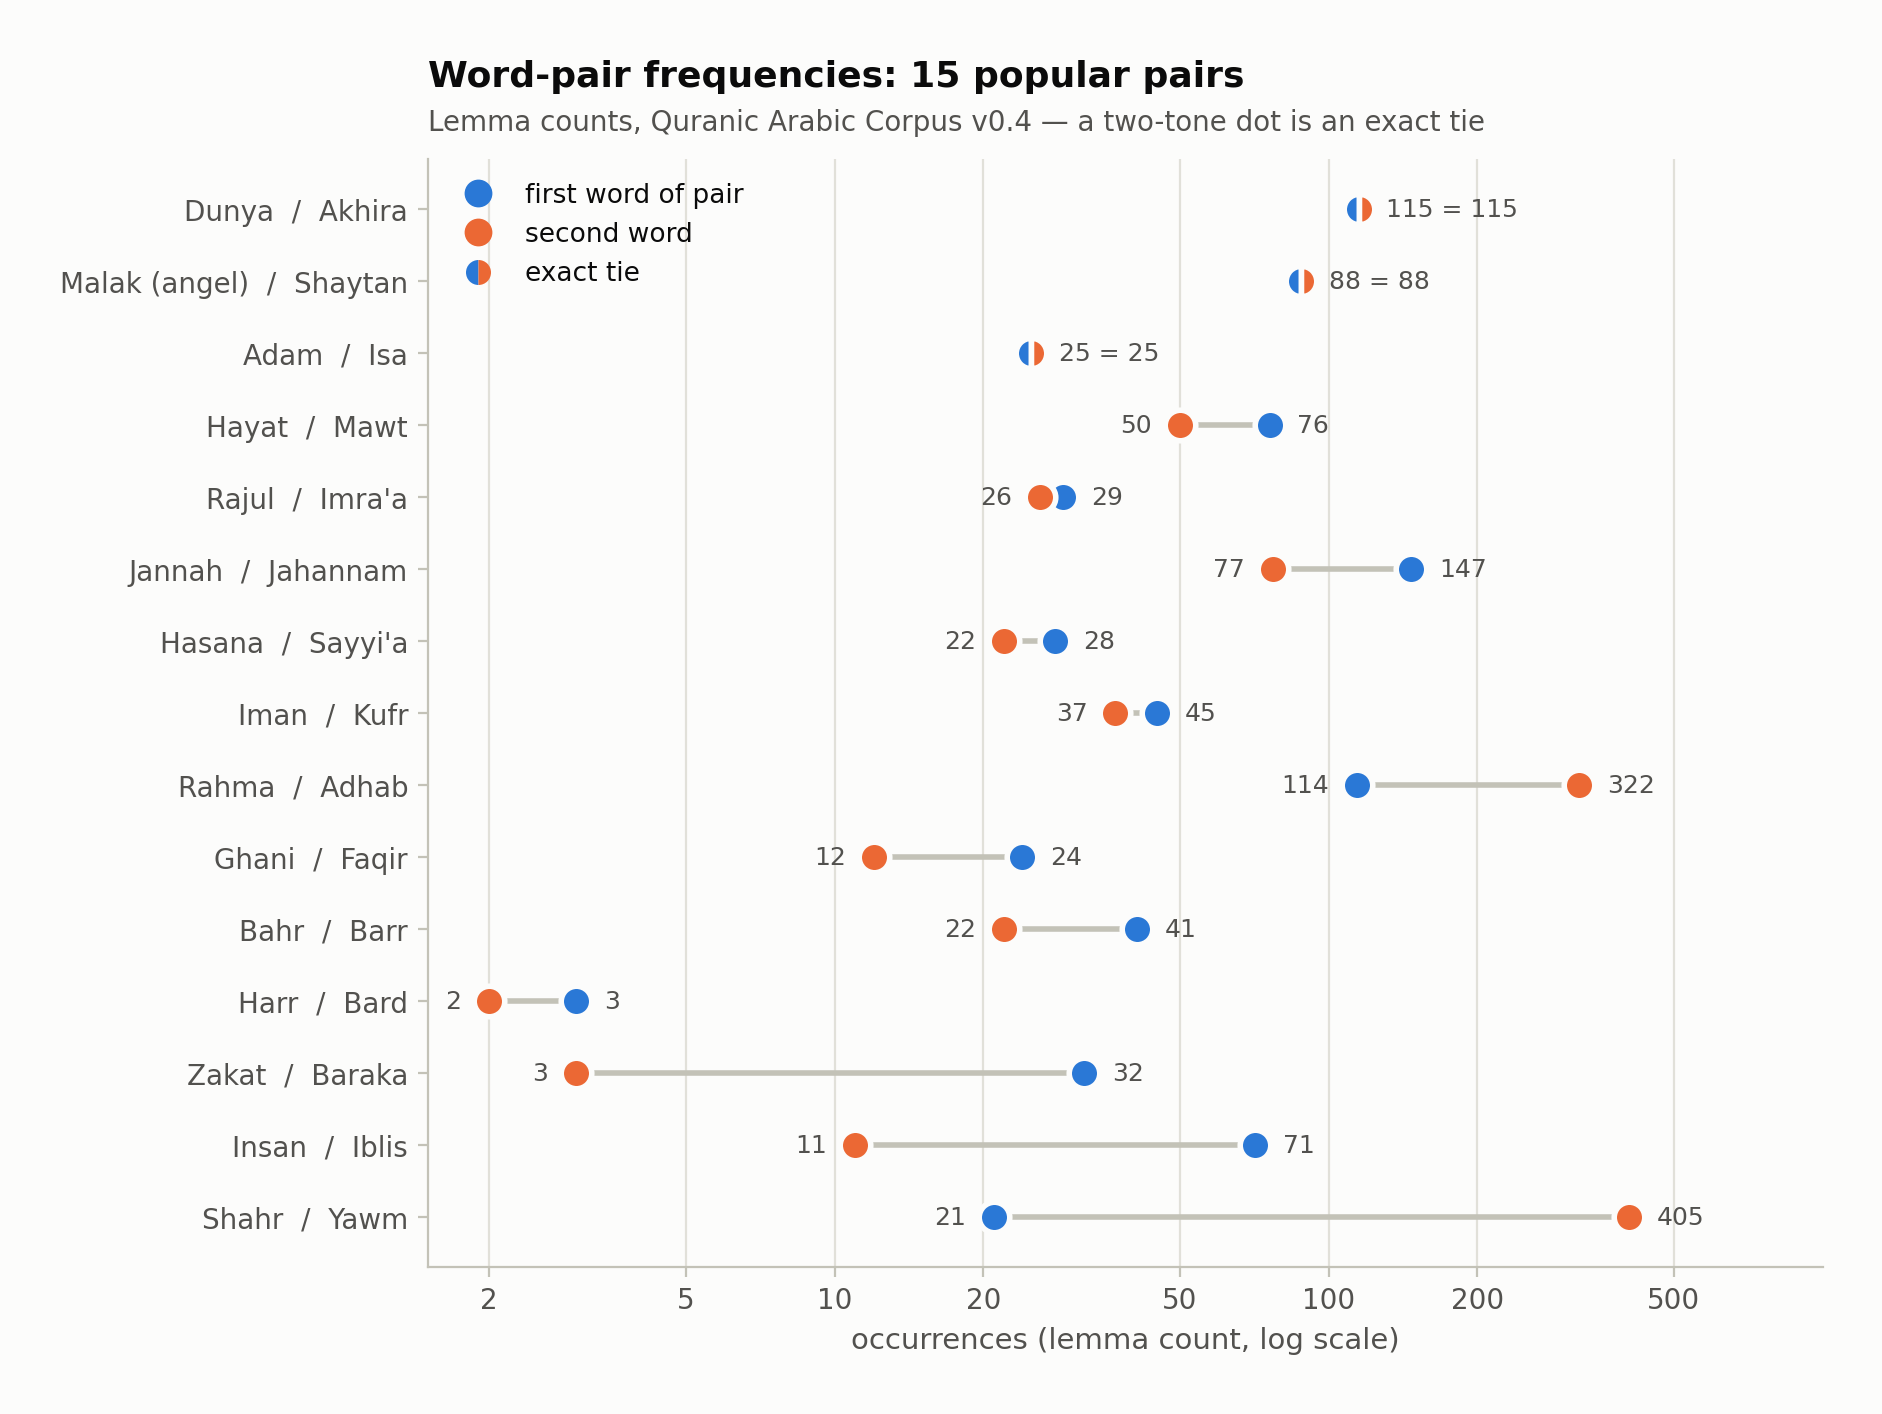

Saved output/pairs.png


In [14]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from src import plotstyle as ps

ps.apply()

PAIRS = [
    ("Dunya", "Akhira"), ("Malak (angel)", "Shaytan"), ("Adam", "Isa"),
    ("Hayat", "Mawt"), ("Rajul", "Imra'a"), ("Jannah", "Jahannam"),
    ("Hasana", "Sayyi'a"), ("Iman", "Kufr"), ("Rahma", "Adhab"),
    ("Ghani", "Faqir"), ("Bahr", "Barr"), ("Harr", "Bard"),
    ("Zakat", "Baraka"), ("Insan", "Iblis"), ("Shahr", "Yawm"),
]
gi = grid.set_index("Word")
counts_a = [int(gi.loc[a, "Lemma"]) for a, _ in PAIRS]
counts_b = [int(gi.loc[b, "Lemma"]) for _, b in PAIRS]

fig, ax = plt.subplots(figsize=(9, 7.2))
y = np.arange(len(PAIRS))[::-1]  # first pair on top
for yi, ca, cb in zip(y, counts_a, counts_b):
    if ca == cb:
        ax.plot([ca], [yi], marker="o", ms=11, ls="none", fillstyle="left",
                mfc=ps.BLUE, mfcalt=ps.ORANGE, mec=ps.SURFACE, mew=2, zorder=3)
        ax.annotate(f"{ca} = {cb}", (ca, yi), xytext=(10, 0), textcoords="offset points",
                    va="center", fontsize=9, color=ps.INK_2)
    else:
        ax.plot([ca, cb], [yi, yi], color=ps.BASELINE, lw=2, zorder=2)
        ax.plot([ca], [yi], "o", ms=11, color=ps.BLUE, mec=ps.SURFACE, mew=2, zorder=3)
        ax.plot([cb], [yi], "o", ms=11, color=ps.ORANGE, mec=ps.SURFACE, mew=2, zorder=3)
        lo, hi = sorted([ca, cb])
        ax.annotate(str(lo), (lo, yi), xytext=(-10, 0), textcoords="offset points",
                    va="center", ha="right", fontsize=9, color=ps.INK_2)
        ax.annotate(str(hi), (hi, yi), xytext=(10, 0), textcoords="offset points",
                    va="center", fontsize=9, color=ps.INK_2)

ax.set_xscale("log")
ax.set_xlim(1.5, 1000)
ax.set_xticks([2, 5, 10, 20, 50, 100, 200, 500], ["2", "5", "10", "20", "50", "100", "200", "500"])
ax.minorticks_off()
ax.grid(False, axis="y")
ax.set_yticks(y, [f"{a}  /  {b}" for a, b in PAIRS])
ax.set_xlabel("occurrences (lemma count, log scale)")
handles = [
    Line2D([], [], marker="o", ls="none", ms=9, color=ps.BLUE, label="first word of pair"),
    Line2D([], [], marker="o", ls="none", ms=9, color=ps.ORANGE, label="second word"),
    Line2D([], [], marker="o", ls="none", ms=9, fillstyle="left",
           mfc=ps.BLUE, mfcalt=ps.ORANGE, mec="none", label="exact tie"),
]
ax.legend(handles=handles, loc="upper left", fontsize=9.5)
ps.titles(ax, "Word-pair frequencies: 15 popular pairs",
          "Lemma counts, Quranic Arabic Corpus v0.4 — a two-tone dot is an exact tie")
ps.save(fig, "../output/pairs.png")
from IPython.display import Image
display(Image("../output/pairs.png"))
print("Saved output/pairs.png")


## 9. External cross-validation (corpus.quran.com, checked 2026-06-11)

The corpus website dictionary (`https://corpus.quran.com/qurandictionary.jsp?q=ROOT`, Buckwalter
root in `q`) runs a later revision of the same annotation project. **Every root used by the 38
target words was fetched and compared** (done outside this notebook so it has no network
dependency). Result: **all compared numbers matched exactly** — every root total and every
per-lemma count on every fetched page, ~140 numbers in all.

Root totals verified (this notebook = website):
dnw 133, Axr 250, mlk 206, $Tn 88, Hyy 184, mwt 165, rjl 73, mrA 38, $hr 21, ywm 405, bHr 42,
brr 32, jnn 201, Hrr 15, brd 5, zkw 59, brk 32, qwl 1722, E*b 373, rHm 339, gfr 234, gny 73,
fqr 14, Hsn 194, swA 167, Ans 97, Amn 879, kfr 525, trb 22, nTf 12, Elq 7, mDg 3, EZm 128,
lHm 12, nsw 59.

Highlights tied to the audit corrections:

| Check | This notebook | corpus.quran.com | Match |
|---|---|---|---|
| A^xir (last + hereafter) | 155 | 155 | ✓ (README's old 145 was wrong) |
| Root EZm: EaZiym / EaZom / >aEoZam / verbs | 120 / 2 / 3 / 3 | same | ✓ |
| bar~ / bir~ / tabar~u (root brr) | 22 / 8 / 2 | same | ✓ |
| Hayaw`p / m~aHoyaA / HayawaAn | 76 / 2 / 1 | same | ✓ |
| mawot / mawotat / mamaAt | 50 / 3 / 3 | same | ✓ |
| qaAla / qawol / qiyl / qaA^}il / >aqaAwiyl / taqaw~ala | 1618 / 92 / 4 / 5 / 1 / 2 | same | ✓ |
| <insa`n / <ins | 71 / 18 | same | ✓ |
| Small-count words incl. verse refs (brd, mDg) | barod 21:69, 78:24; barad 24:43; baArid 38:42, 56:44; muDogap 22:5, 23:14×2 | same | ✓ |

The EZm page also confirms the bones finding: the website glosses the ʿiẓām entries as
"[the bones]" (e.g. 2:259:51, 23:14:10, 75:3:5) while still filing them under the ʿaẓīm
lemma — i.e. the conflation is an upstream annotation decision, present in the current
revision too, not a v0.4 parsing artifact. Counting "bones" therefore *requires* the
`(EaZiym, N, P)` selector used in this notebook.

Proper nouns without a root (Jahannam, Isa, Iblis) are not reachable through the root
dictionary; Adam (25) was confirmed via its dictionary page, and all four are covered by the
token-level validation below.

### 9.1 Token-level validation via JQuranTree (TASK.txt's named cross-check)

`validation/validate_locations.py` + `validation/DumpTokens.java` reconstruct the full token
(prefixes + stem + suffixes) for **every one of the 3,960 unique locations counted in
`occurrences.csv`** from the morphology file, and compare its letter skeleton against the token
at the same chapter:verse:word in the canonical Tanzil Uthmani text, accessed through
[JQuranTree](https://github.com/dsog/jqurantree) (the corpus project's official Java API).

Result (2026-06-11, report in `validation/token_validation_report.txt`):

```
locations checked     : 3960
letter-skeleton match : 3960
mismatches            : 0
missing tokens        : 0
```

Every counted occurrence is a real word at exactly the claimed location in the Quran text.
(Normalization notes: hamza seats map to their carrier letter and the Uthmani dagger alif counts
as a full alif, matching Tanzil's orthography; Uthmani recitation marks are excluded on both
sides.)

## 10. Tooling note

Considered alternatives to the in-repo parser: **JQuranTree** (the official Java API),
**QuranTree.jl** (Julia), and the pip package `qurancorpus` (abandoned, 2 commits, parses the
obsolete v0.1 XML format only). None fits a Python/pandas workflow for the v0.4 TSV better than
direct parsing of the documented tab-separated format, which is standard practice for this
dataset. `src/parser.py` is verified 1:1 against the raw file (cell 1) and against the corpus
website (section 9).

## 11. Replication

1. Every count derives from `data/quranic-corpus-morphology-0.4.txt` via `src/parser.py`;
   re-run this notebook top to bottom to reproduce, or load `output/full_counts.csv` /
   `output/occurrences.csv`.
2. To verify any single number by hand: filter `output/occurrences.csv` to the word, and look up
   each chapter:verse:word location in any Quran text or on https://corpus.quran.com.